<a href="https://colab.research.google.com/github/Syedsec12/developershub-data-science-internship/blob/main/Task5_Titanic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_182/357044983.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


Accuracy: 0.7988826815642458
Confusion Matrix:
 [[89 16]
 [20 54]]


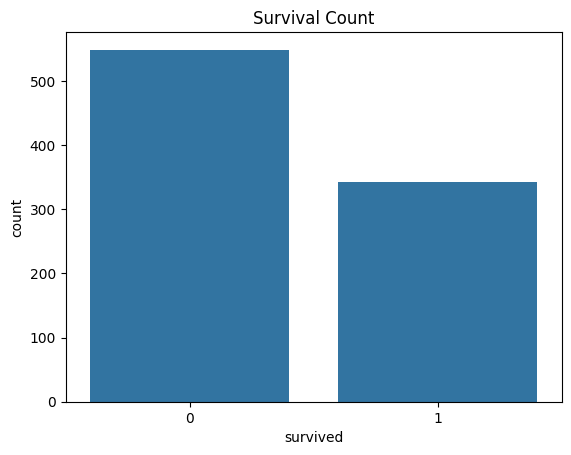

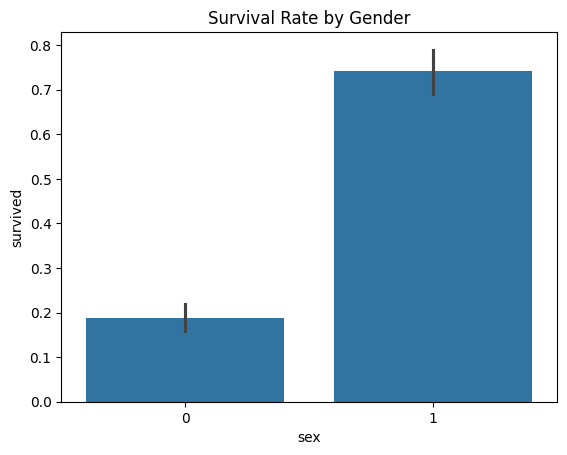

In [19]:
# Step 0: Libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 1: Load Dataset
df = sns.load_dataset('titanic')

# Step 2: Select Required Columns
df = df[['survived','pclass','sex','age','fare']]

# Step 3: Handle Missing Values
df['age'].fillna(df['age'].mean(), inplace=True)

# Step 4: Convert categorical to numeric
df['sex'] = df['sex'].map({'male':0, 'female':1})

# Step 5: Features & Target
X = df.drop('survived', axis=1)
y = df['survived']

# Step 6: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 8: Prediction
y_pred = model.predict(X_test)

# Step 9: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Step 10: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Step 11: Basic Graphs
# a) Survival Count
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

# b) Gender vs Survival
sns.barplot(x='sex', y='survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

# Conclusion
- Logistic Regression model used to predict Titanic survival.
- Model accuracy is ~80%, which is reasonable for this simple model.
- Confusion matrix shows correct predictions vs misclassifications.
- Females have a higher survival rate compared to males.
- Pclass (Passenger Class) and age also influence survival probabilities.
- This task demonstrates basic data preprocessing, classification modeling, and visualization skills.